# ⚡ PJM AEP Energy Consumption Forecasting
## Comparing SARIMAX vs LSTM vs XGBoost

**Dataset:** PJM Hourly Energy Consumption — AEP Region (Ohio)  
**Models:** SARIMAX · LSTM · XGBoost  
**Metric:** RMSE, MAE, MAPE  

---
### 📦 Installation
```bash
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels tensorflow xgboost kaggle
```

### 📥 Download Dataset
From Kaggle: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption  
Download `AEP_hourly.csv` and place it in the same folder as this notebook.

---
## 1. 📚 Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# ML
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Config
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version: {np.__version__}')
print('✅ All libraries loaded successfully!')

TensorFlow version: 2.20.0
NumPy version: 2.4.2
✅ All libraries loaded successfully!


---
## 2. 📂 Load & Inspect Data

In [2]:
# Load data
df = pd.read_csv('archive\AEP_hourly.csv', parse_dates=['Datetime'], index_col='Datetime')
df.columns = ['energy_mw']
df = df.sort_index()

print('='*55)
print('📊 DATASET OVERVIEW')
print('='*55)
print(f'Shape          : {df.shape}')
print(f'Date Range     : {df.index.min()} → {df.index.max()}')
print(f'Total Hours    : {len(df):,}')
print(f'Total Years    : {(df.index.max() - df.index.min()).days / 365:.1f}')
print(f'Missing Values : {df.isnull().sum().values[0]}')
print('\n📈 Energy Stats (MW):')
print(df.describe().round(2))

📊 DATASET OVERVIEW
Shape          : (121273, 1)
Date Range     : 2004-10-01 01:00:00 → 2018-08-03 00:00:00
Total Hours    : 121,273
Total Years    : 13.8
Missing Values : 0

📈 Energy Stats (MW):
       energy_mw
count  121273.00
mean    15499.51
std      2591.40
min      9581.00
25%     13630.00
50%     15310.00
75%     17200.00
max     25695.00


In [4]:
# Handle missing timestamps by reindexing to complete hourly range
# Drop duplicate timestamps first (AEP_hourly.csv contains some)
df = df[~df.index.duplicated(keep='first')]
print(f'Duplicates removed. Shape: {df.shape}')
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
df = df.reindex(full_range)
df['energy_mw'] = df['energy_mw'].interpolate(method='time')
print(f'After reindex: {df.shape}, Missing: {df.isnull().sum().values[0]}')

Duplicates removed. Shape: (121269, 1)
After reindex: (121296, 1), Missing: 0


---
## 3. 🔍 Exploratory Data Analysis

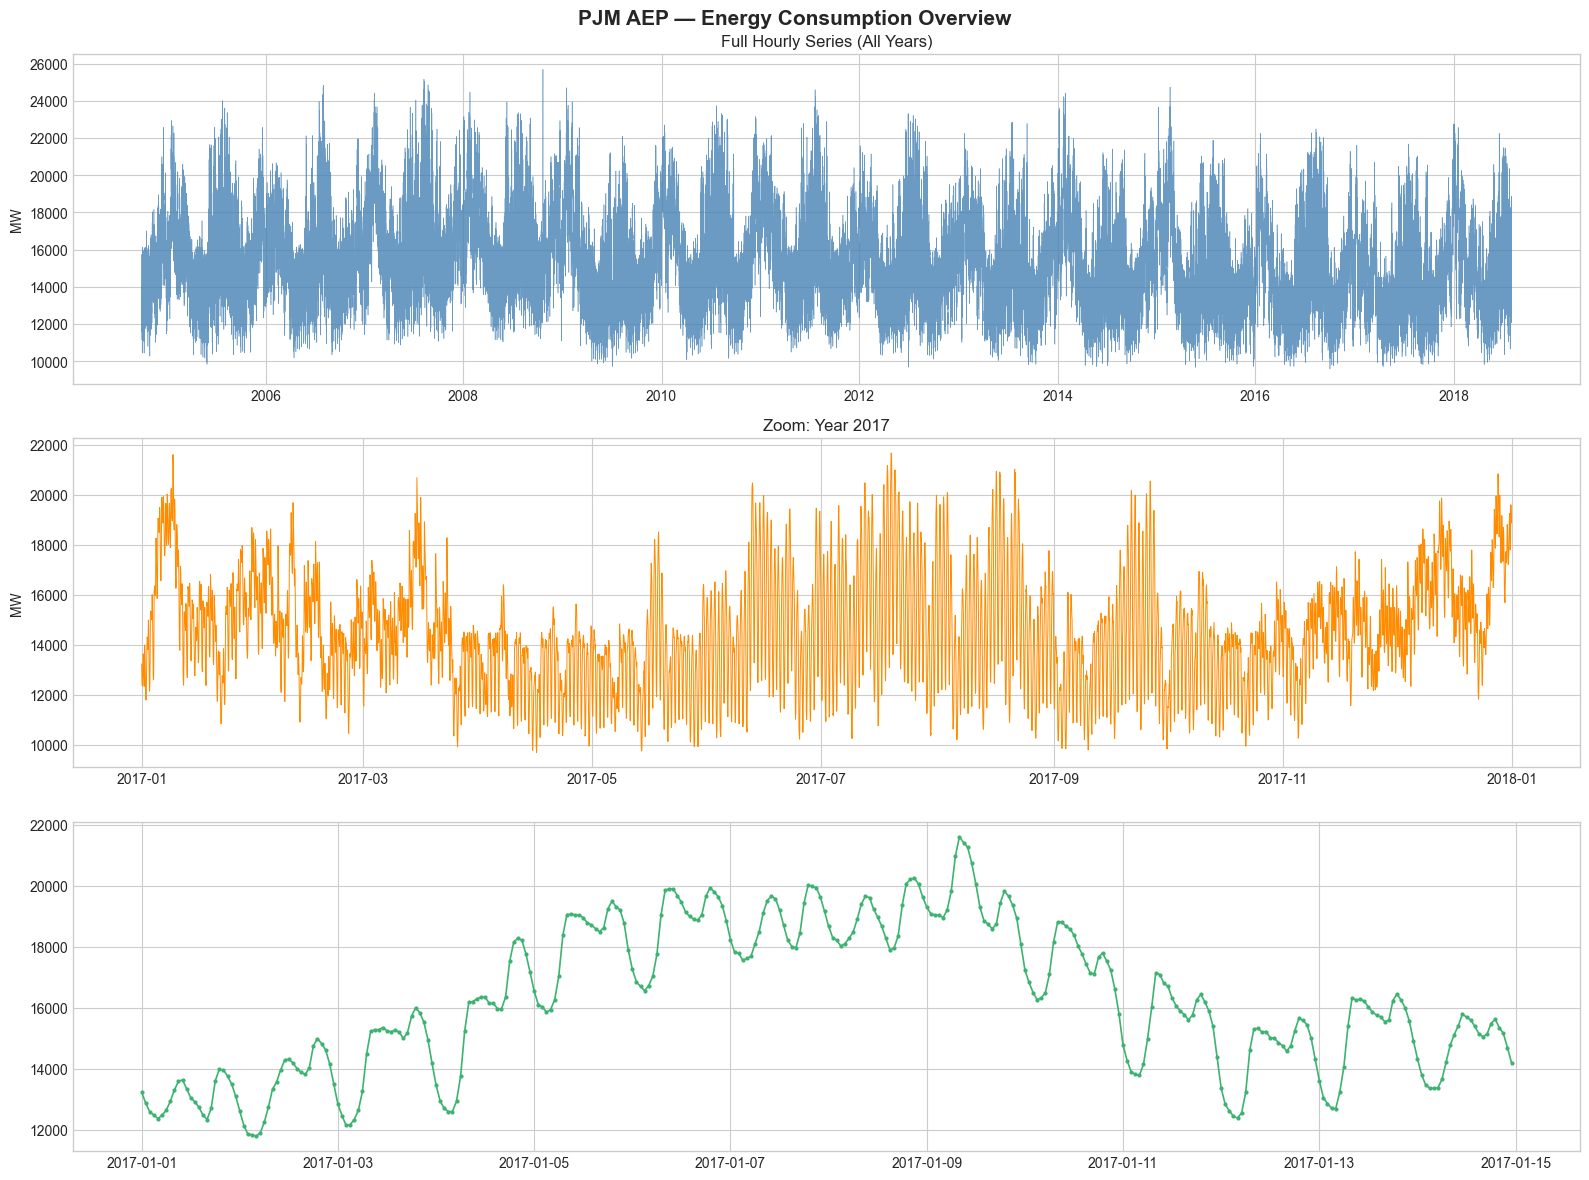

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('PJM AEP — Energy Consumption Overview', fontsize=15, fontweight='bold')

# Full series
axes[0].plot(df.index, df['energy_mw'], linewidth=0.4, color='steelblue', alpha=0.8)
axes[0].set_title('Full Hourly Series (All Years)')
axes[0].set_ylabel('MW')

# One year zoom
axes[1].plot(df.loc['2017'].index, df.loc['2017']['energy_mw'], linewidth=0.7, color='darkorange')
axes[1].set_title('Zoom: Year 2017')
axes[1].set_ylabel('MW')
# One week zoom
axes[2].plot(df.loc['2017-01-01':'2017-01-14'].index, 
             df.loc['2017-01-01':'2017-01-14']['energy_mw'], 
             linewidth=1.2, color='mediumseagreen', marker='o', markersize=2)

plt.tight_layout()
plt.savefig('01_overview.png', dpi=120, bbox_inches='tight')
plt.show()

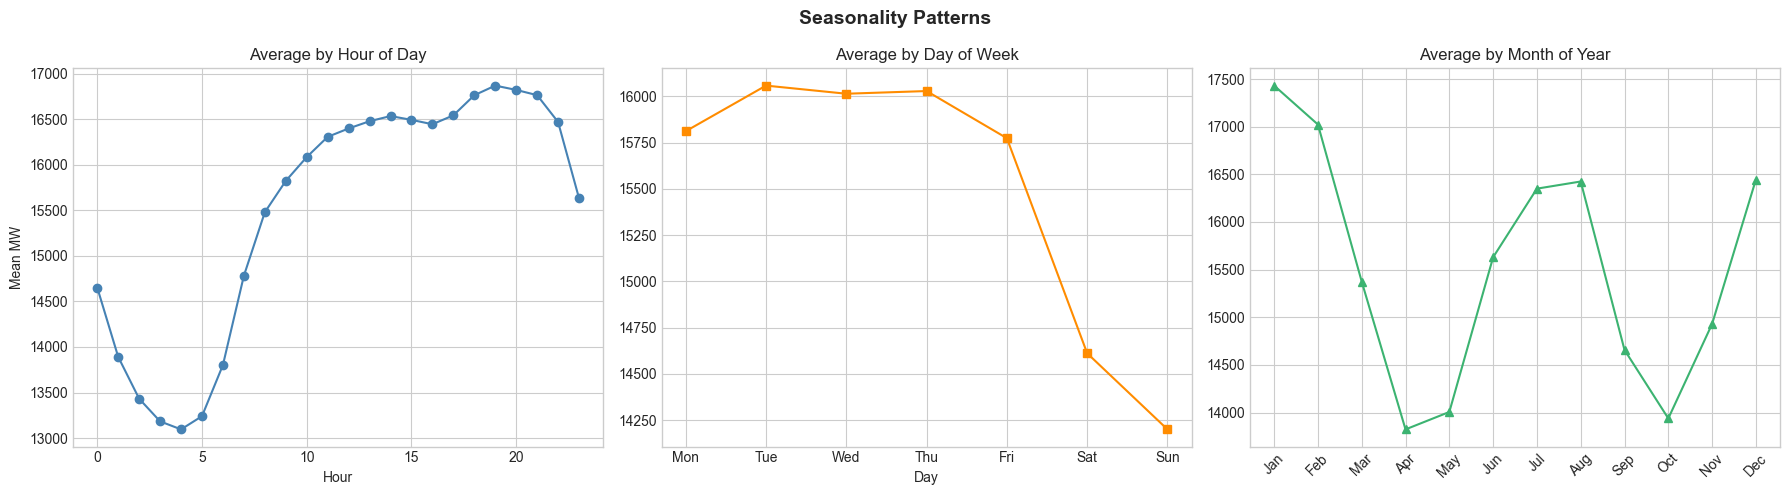

In [7]:
# Seasonality Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Seasonality Patterns', fontsize=14, fontweight='bold')

# Hour of day
df.groupby(df.index.hour)['energy_mw'].mean().plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Average by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean MW')

# Day of week
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df.groupby(df.index.dayofweek)['energy_mw'].mean().plot(ax=axes[1], marker='s', color='darkorange')
axes[1].set_title('Average by Day of Week')
axes[1].set_xticklabels([''] + days)
axes[1].set_xlabel('Day')

# Month of year
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df.groupby(df.index.month)['energy_mw'].mean().plot(ax=axes[2], marker='^', color='mediumseagreen')
axes[2].set_title('Average by Month of Year')
axes[2].set_xticks(range(1,13))
axes[2].set_xticklabels(months, rotation=45)

plt.tight_layout()
plt.savefig('02_seasonality.png', dpi=120, bbox_inches='tight')
plt.show()

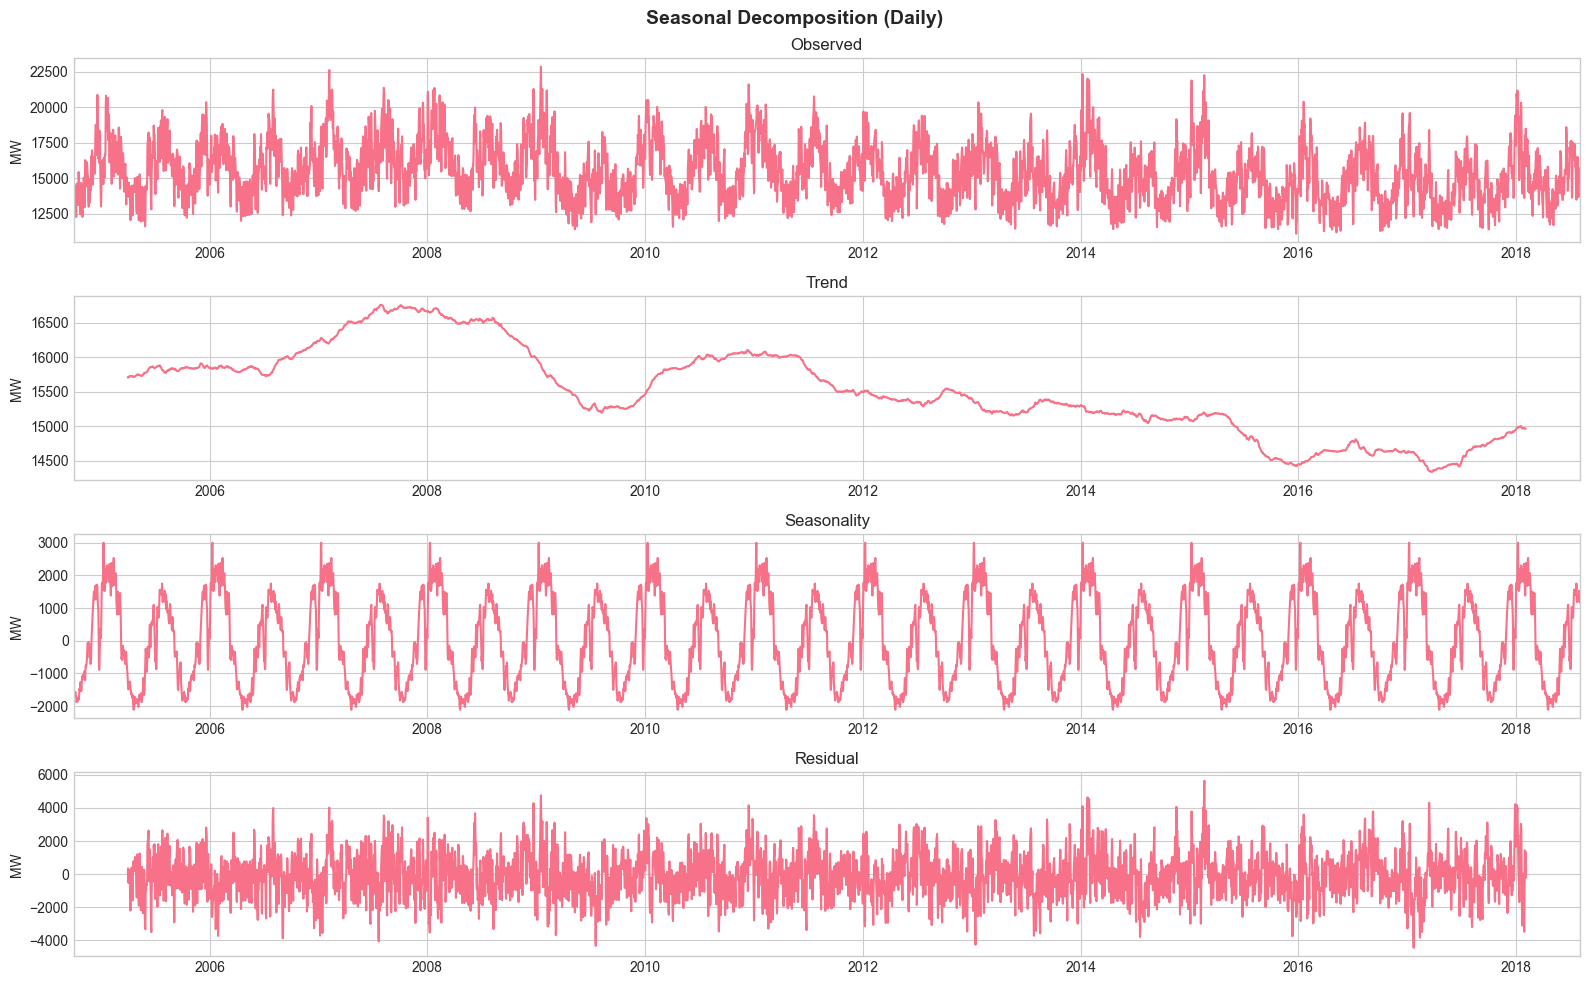

In [8]:
# Seasonal Decomposition (on daily resampled data for speed)
daily = df['energy_mw'].resample('D').mean()
decomp = seasonal_decompose(daily, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 10))
fig.suptitle('Seasonal Decomposition (Daily)', fontsize=14, fontweight='bold')

decomp.observed.plot(ax=axes[0]);  axes[0].set_title('Observed');   axes[0].set_ylabel('MW')
decomp.trend.plot(ax=axes[1]);     axes[1].set_title('Trend');      axes[1].set_ylabel('MW')
decomp.seasonal.plot(ax=axes[2]);  axes[2].set_title('Seasonality');axes[2].set_ylabel('MW')
decomp.resid.plot(ax=axes[3]);     axes[3].set_title('Residual');   axes[3].set_ylabel('MW')

plt.tight_layout()
plt.savefig('03_decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. 🔬 Stationarity Tests

In [9]:
def test_stationarity(series, name='Series'):
    print(f'\n{'='*50}')
    print(f'Stationarity Tests: {name}')
    print(f'{'='*50}')
    
    # ADF Test
    adf_result = adfuller(series.dropna(), autolag='AIC')
    print(f'\n[ADF Test] — H0: Unit root (non-stationary)')
    print(f'  Statistic : {adf_result[0]:.4f}')
    print(f'  p-value   : {adf_result[1]:.4f}')
    print(f'  Conclusion: {"✅ STATIONARY (reject H0)" if adf_result[1] < 0.05 else "❌ NON-STATIONARY"}')
    
    # KPSS Test
    kpss_result = kpss(series.dropna(), regression='c')
    print(f'\n[KPSS Test] — H0: Stationary')
    print(f'  Statistic : {kpss_result[0]:.4f}')
    print(f'  p-value   : {kpss_result[1]:.4f}')
    print(f'  Conclusion: {"✅ STATIONARY (fail to reject H0)" if kpss_result[1] > 0.05 else "❌ NON-STATIONARY"}')

# Test on daily data
test_stationarity(daily, 'Daily Energy (Original)')
test_stationarity(daily.diff().dropna(), 'Daily Energy (First Difference)')


Stationarity Tests: Daily Energy (Original)

[ADF Test] — H0: Unit root (non-stationary)
  Statistic : -7.4888
  p-value   : 0.0000
  Conclusion: ✅ STATIONARY (reject H0)

[KPSS Test] — H0: Stationary
  Statistic : 1.7203
  p-value   : 0.0100
  Conclusion: ❌ NON-STATIONARY

Stationarity Tests: Daily Energy (First Difference)

[ADF Test] — H0: Unit root (non-stationary)
  Statistic : -16.2223
  p-value   : 0.0000
  Conclusion: ✅ STATIONARY (reject H0)

[KPSS Test] — H0: Stationary
  Statistic : 0.0115
  p-value   : 0.1000
  Conclusion: ✅ STATIONARY (fail to reject H0)


C:\Users\mesut\AppData\Local\Temp\ipykernel_24220\1689623534.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')
C:\Users\mesut\AppData\Local\Temp\ipykernel_24220\1689623534.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


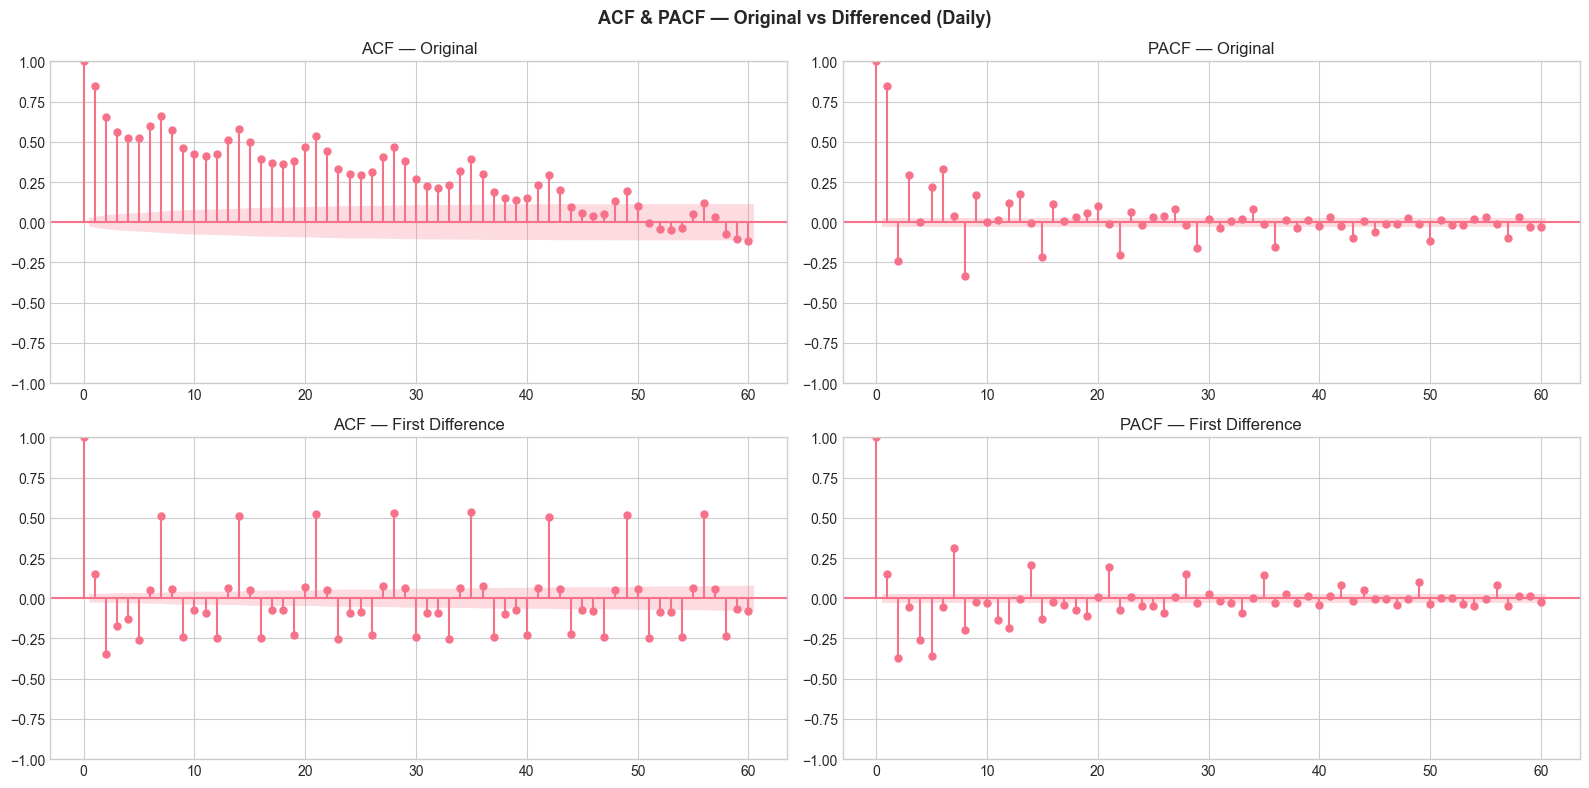

In [10]:
# ACF / PACF plots
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('ACF & PACF — Original vs Differenced (Daily)', fontsize=13, fontweight='bold')

plot_acf(daily.dropna(),  lags=60, ax=axes[0,0], title='ACF — Original')
plot_pacf(daily.dropna(), lags=60, ax=axes[0,1], title='PACF — Original')
plot_acf(daily.diff().dropna(),  lags=60, ax=axes[1,0], title='ACF — First Difference')
plot_pacf(daily.diff().dropna(), lags=60, ax=axes[1,1], title='PACF — First Difference')

plt.tight_layout()
plt.savefig('04_acf_pacf.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. ✂️ Train/Test Split

We use **daily** resampled data for SARIMAX (hourly is too large for SARIMAX).  
For LSTM and XGBoost we'll also use daily to ensure a fair comparison.

- **Train:** All data up to 2017-12-31
- **Test:** 2018 (last ~1 year)

Train: 2004-10-01 → 2017-12-31  (4840 days)
Test : 2018-01-01  → 2018-08-03  (215 days)


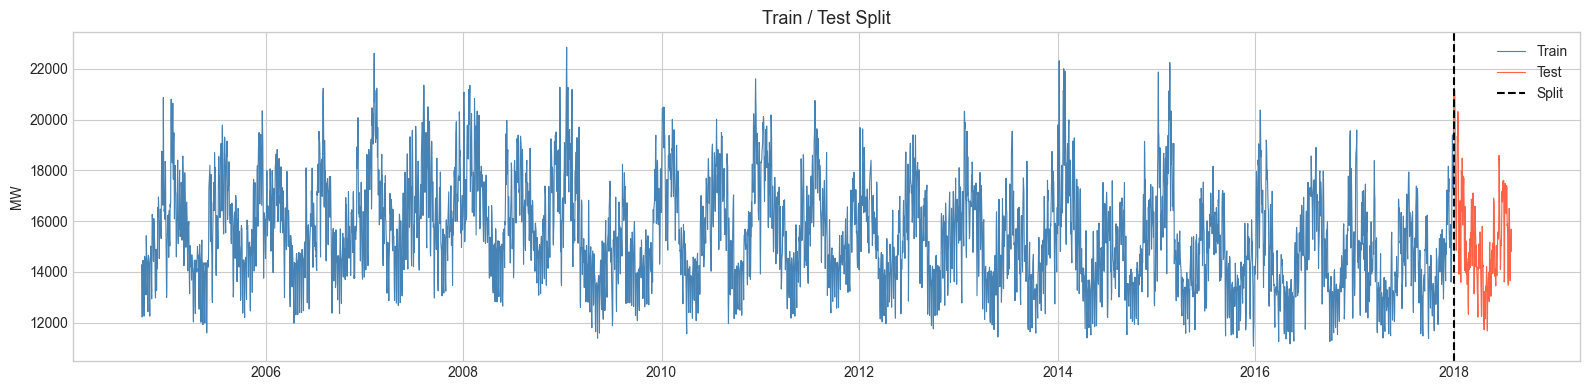

In [11]:
# Use daily data for all models (fair comparison)
data = df['energy_mw'].resample('D').mean().dropna()

SPLIT_DATE = '2017-12-31'
train = data[:SPLIT_DATE]
test  = data['2018':]

print(f'Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train)} days)')
print(f'Test : {test.index.min().date()}  → {test.index.max().date()}  ({len(test)} days)')

# Plot split
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(train.index, train, label='Train', color='steelblue', linewidth=0.8)
ax.plot(test.index,  test,  label='Test',  color='tomato',    linewidth=0.8)
ax.axvline(pd.Timestamp('2018-01-01'), color='black', linestyle='--', linewidth=1.5, label='Split')
ax.set_title('Train / Test Split', fontsize=13)
ax.set_ylabel('MW')
ax.legend()
plt.tight_layout()
plt.savefig('05_train_test_split.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. 📐 Helper Functions

In [12]:
def evaluate_model(y_true, y_pred, model_name):
    """Calculate and display evaluation metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f'\n📊 {model_name} Results:')
    print(f'  RMSE : {rmse:>10,.2f} MW')
    print(f'  MAE  : {mae:>10,.2f} MW')
    print(f'  MAPE : {mape:>10,.2f} %')
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


def plot_forecast(train, test, pred, model_name, color='darkorange'):
    """Plot actual vs predicted with zoom panels."""
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    fig.suptitle(f'{model_name} — Forecast vs Actual', fontsize=14, fontweight='bold')

    # Full view (last year of train + test)
    axes[0].plot(train[-90:].index, train[-90:], label='Train (last 90d)', 
                 color='steelblue', linewidth=1)
    axes[0].plot(test.index, test.values,     label='Actual', color='black', linewidth=1.2)
    axes[0].plot(test.index, pred,            label='Forecast', color=color, 
                 linewidth=1.2, linestyle='--')
    axes[0].set_title('Full Test Period')
    axes[0].set_ylabel('MW')
    axes[0].legend()

    # Zoom: first 60 days
    axes[1].plot(test.index[:60], test.values[:60], label='Actual',   color='black',  linewidth=1.5)
    axes[1].plot(test.index[:60], pred[:60],        label='Forecast', color=color,    linewidth=1.5, linestyle='--')
    axes[1].fill_between(test.index[:60], test.values[:60], pred[:60], alpha=0.15, color=color)
    axes[1].set_title('Zoom: First 60 Days of Test Period')
    axes[1].set_ylabel('MW')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ","_")}_forecast.png', dpi=120, bbox_inches='tight')
    plt.show()


# Store results
results = []
print('✅ Helper functions ready.')

✅ Helper functions ready.


---
## 7. 📈 Model 1 — SARIMAX

**Configuration:**
- Order `(p,d,q)` = `(1,1,1)` — AR, differencing, MA terms
- Seasonal order `(P,D,Q,s)` = `(1,1,1,7)` — weekly seasonality (s=7 days)
- Exogenous features: month dummies, day-of-week dummies

In [13]:
# Feature engineering for SARIMAX exogenous variables
def make_exog(series):
    df_ex = pd.DataFrame(index=series.index)
    df_ex['month']      = series.index.month
    df_ex['dayofweek']  = series.index.dayofweek
    df_ex['is_weekend'] = (series.index.dayofweek >= 5).astype(int)
    df_ex['quarter']    = series.index.quarter
    return df_ex

exog_train = make_exog(train)
exog_test  = make_exog(test)

print('Exogenous shape:', exog_train.shape)
exog_train.head()

Exogenous shape: (4840, 4)


,month,dayofweek,is_weekend,quarter
2004-10-01,10,4,0,4
2004-10-02,10,5,1,4
2004-10-03,10,6,1,4
2004-10-04,10,0,0,4
2004-10-05,10,1,0,4


In [14]:
%%time
print('🔧 Fitting SARIMAX(1,1,1)(1,1,1,7) — this may take a few minutes...')

sarimax_model = SARIMAX(
    train,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False)
print('✅ SARIMAX fitted!')
print(sarimax_result.summary())

🔧 Fitting SARIMAX(1,1,1)(1,1,1,7) — this may take a few minutes...
✅ SARIMAX fitted!
                                     SARIMAX Results                                     
Dep. Variable:                         energy_mw   No. Observations:                 4840
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -38611.635
Date:                           Mon, 02 Mar 2026   AIC                          77241.271
Time:                                   14:09:03   BIC                          77299.601
Sample:                               10-01-2004   HQIC                         77261.752
                                    - 12-31-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month        -21.9761     41.910     

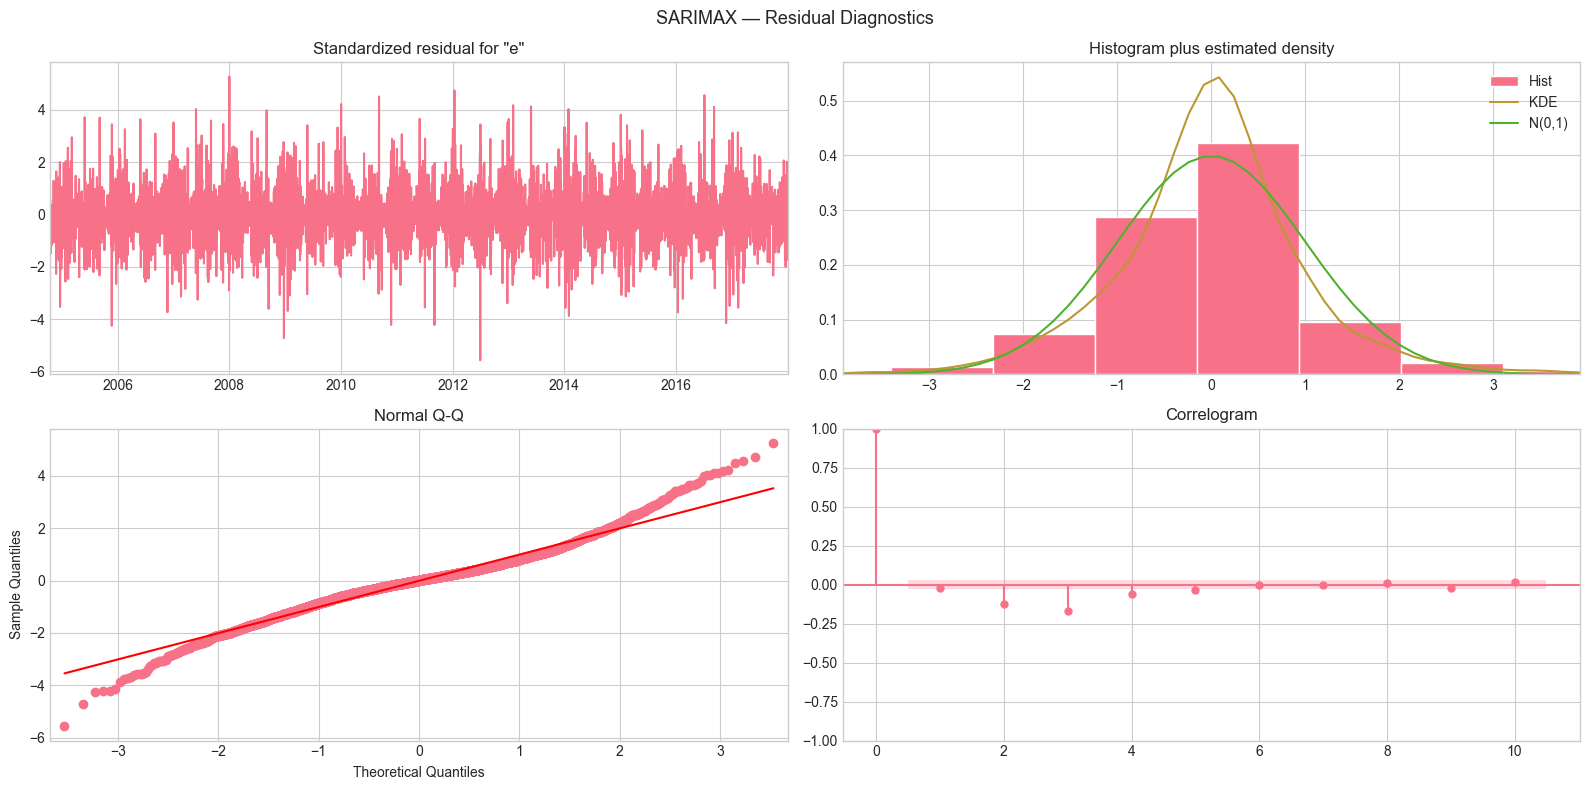

In [15]:
# Diagnostic plots
fig = sarimax_result.plot_diagnostics(figsize=(16, 8))
fig.suptitle('SARIMAX — Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.savefig('sarimax_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()


📊 SARIMAX Results:
  RMSE :   5,212.72 MW
  MAE  :   4,914.53 MW
  MAPE :      33.81 %


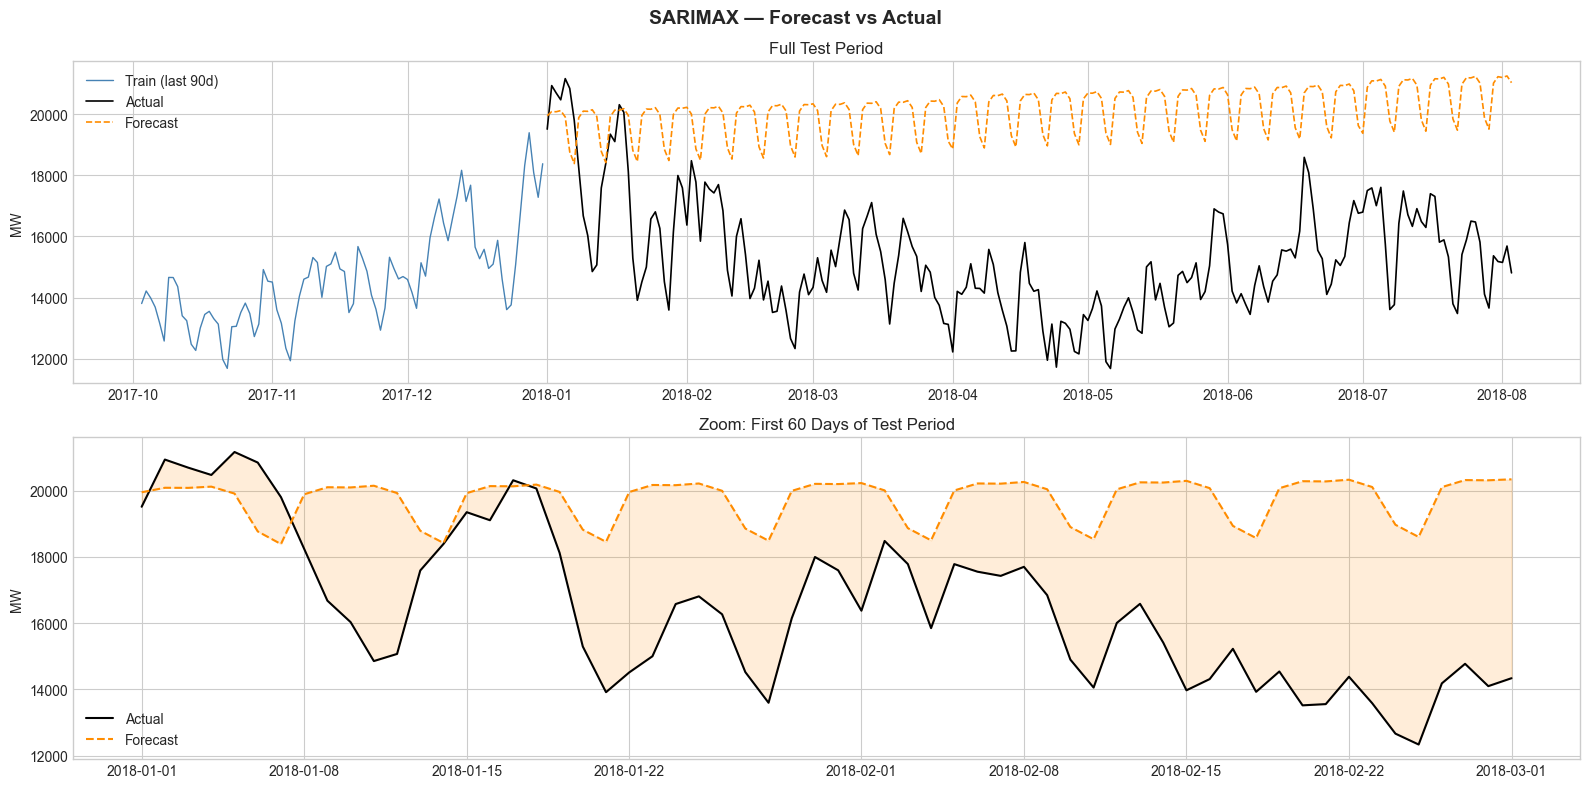

In [16]:
# Forecast
sarimax_forecast = sarimax_result.forecast(steps=len(test), exog=exog_test)
sarimax_pred = np.maximum(sarimax_forecast.values, 0)  # clip negatives

# Evaluate
sarimax_metrics = evaluate_model(test.values, sarimax_pred, 'SARIMAX')
results.append(sarimax_metrics)

# Plot
plot_forecast(train, test, sarimax_pred, 'SARIMAX', color='darkorange')

---
## 8. 🧠 Model 2 — LSTM

**Architecture:**
- Input: 60-day lookback window
- 2 LSTM layers + Dropout regularization
- Dense output layer
- EarlyStopping + ReduceLROnPlateau callbacks

In [17]:
# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled  = scaler.transform(test.values.reshape(-1, 1))

def create_sequences(data, lookback=60):
    """Create (X, y) sequences for LSTM."""
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

LOOKBACK = 60

X_train, y_train = create_sequences(train_scaled, LOOKBACK)

# For test: append last LOOKBACK days of train to provide initial context
combined = np.concatenate([train_scaled[-LOOKBACK:], test_scaled])
X_test, y_test = create_sequences(combined, LOOKBACK)

# Reshape for LSTM: (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],   X_test.shape[1],  1)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  | y_test : {y_test.shape}')

X_train: (4780, 60, 1) | y_train: (4780,)
X_test : (215, 60, 1)  | y_test : (215,)


In [18]:
# Build LSTM model
def build_lstm(lookback, units=64):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(0.2),
        LSTM(units // 2, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

lstm_model = build_lstm(LOOKBACK, units=64)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,401 (118.75 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
%%time
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
print('✅ LSTM training complete!')

Epoch 1/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - loss: 0.0215 - mae: 0.1124 - val_loss: 0.0140 - val_mae: 0.0919 - learning_rate: 0.0010
Epoch 2/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0158 - mae: 0.0981 - val_loss: 0.0129 - val_mae: 0.0883 - learning_rate: 0.0010
Epoch 3/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0147 - mae: 0.0950 - val_loss: 0.0121 - val_mae: 0.0862 - learning_rate: 0.0010
Epoch 4/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0142 - mae: 0.0937 - val_loss: 0.0116 - val_mae: 0.0845 - learning_rate: 0.0010
Epoch 5/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - loss: 0.0134 - mae: 0.0914 - val_loss: 0.0108 - val_mae: 0.0814 - learning_rate: 0.0010
Epoch 6/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - loss: 0.0123 - mae: 0.0877 - val_loss: 0.0095 - val_mae: 0.0766 - learning_rate: 0.0010
Epoch 7/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - loss: 0.0107 - mae: 0.0810 - val_loss: 0.0077 - val_mae: 0.0688 - learning_ra

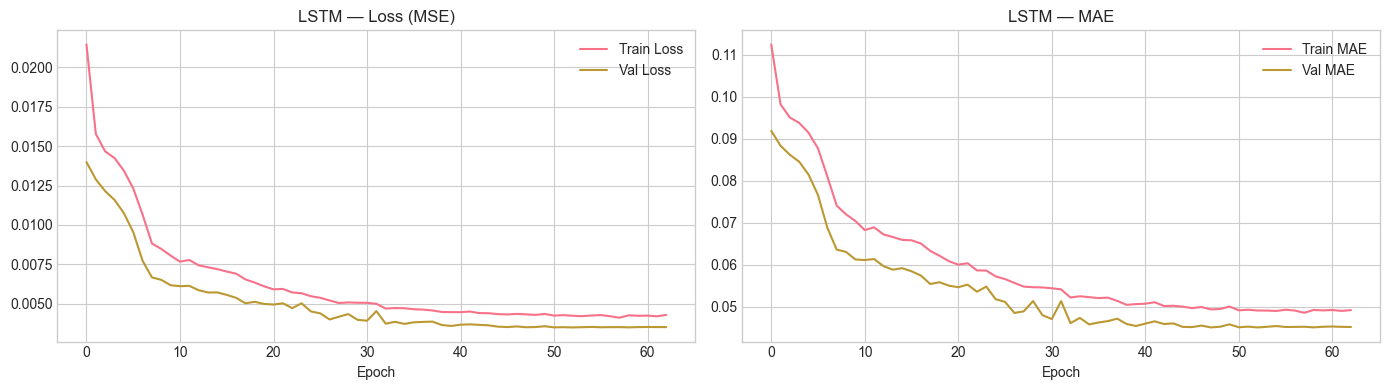

In [20]:
# Training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM — Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('LSTM — MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=120, bbox_inches='tight')
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step

📊 LSTM Results:
  RMSE :     788.04 MW
  MAE  :     618.69 MW
  MAPE :       4.03 %


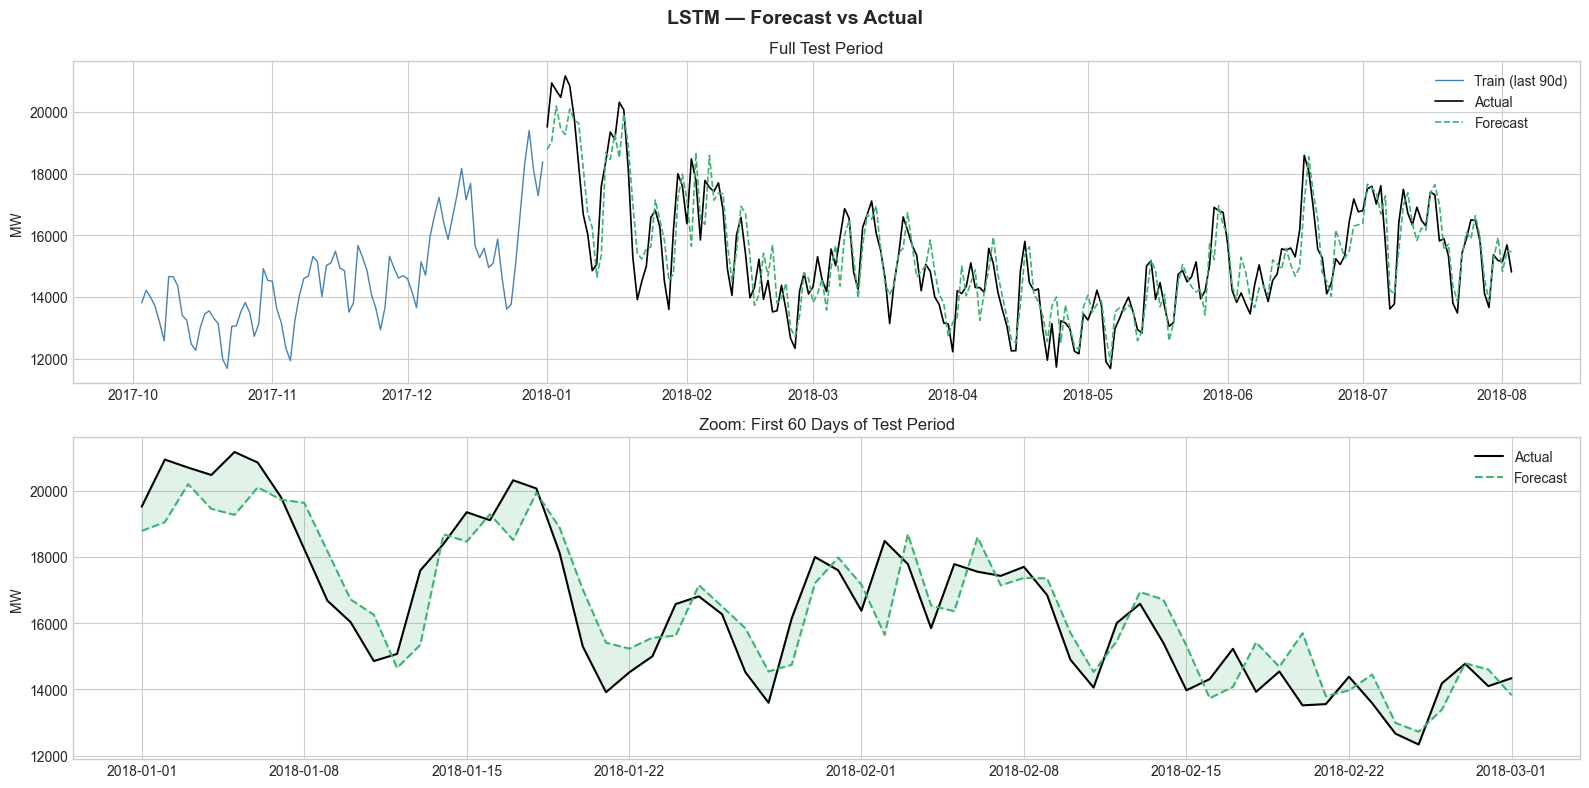

In [21]:
# Forecast and inverse transform
lstm_pred_scaled = lstm_model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()

# Evaluate
lstm_metrics = evaluate_model(test.values, lstm_pred, 'LSTM')
results.append(lstm_metrics)

# Plot
plot_forecast(train, test, lstm_pred, 'LSTM', color='mediumseagreen')

---
## 9. 🌲 Model 3 — XGBoost

**Feature Engineering:**
- Calendar features: hour, dayofweek, month, quarter, year, is_weekend
- Lag features: lag 1, 7, 14, 30, 365 days
- Rolling statistics: rolling mean/std (7-day, 30-day windows)

In [22]:
def create_xgb_features(series):
    """Create rich feature set for XGBoost."""
    df_feat = pd.DataFrame({'energy_mw': series})
    
    # Calendar features
    df_feat['dayofweek']    = df_feat.index.dayofweek
    df_feat['month']        = df_feat.index.month
    df_feat['quarter']      = df_feat.index.quarter
    df_feat['year']         = df_feat.index.year
    df_feat['dayofyear']    = df_feat.index.dayofyear
    df_feat['is_weekend']   = (df_feat.index.dayofweek >= 5).astype(int)
    df_feat['weekofyear']   = df_feat.index.isocalendar().week.astype(int)
    
    # Lag features
    for lag in [1, 7, 14, 30, 365]:
        df_feat[f'lag_{lag}'] = df_feat['energy_mw'].shift(lag)
    
    # Rolling window features
    for window in [7, 30]:
        df_feat[f'rolling_mean_{window}'] = df_feat['energy_mw'].shift(1).rolling(window).mean()
        df_feat[f'rolling_std_{window}']  = df_feat['energy_mw'].shift(1).rolling(window).std()
        df_feat[f'rolling_min_{window}']  = df_feat['energy_mw'].shift(1).rolling(window).min()
        df_feat[f'rolling_max_{window}']  = df_feat['energy_mw'].shift(1).rolling(window).max()
    
    return df_feat

# Build features on full data
full_feat = create_xgb_features(data)
full_feat = full_feat.dropna()

FEATURE_COLS = [c for c in full_feat.columns if c != 'energy_mw']

# Split
xgb_train = full_feat[full_feat.index <= SPLIT_DATE]
xgb_test  = full_feat[full_feat.index >  SPLIT_DATE]

X_tr = xgb_train[FEATURE_COLS]
y_tr = xgb_train['energy_mw']
X_te = xgb_test[FEATURE_COLS]
y_te = xgb_test['energy_mw']

print(f'XGB Train: {X_tr.shape} | Test: {X_te.shape}')
print(f'Features: {FEATURE_COLS}')

XGB Train: (4475, 20) | Test: (215, 20)
Features: ['dayofweek', 'month', 'quarter', 'year', 'dayofyear', 'is_weekend', 'weekofyear', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7', 'rolling_mean_30', 'rolling_std_30', 'rolling_min_30', 'rolling_max_30']


In [23]:
%%time
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_SEED,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_te, y_te)],
    verbose=100
)
print('✅ XGBoost training complete!')

[0]	validation_0-rmse:1821.03481
[100]	validation_0-rmse:820.64454
[200]	validation_0-rmse:820.06626
[217]	validation_0-rmse:818.65862
✅ XGBoost training complete!
CPU times: total: 2.84 s
Wall time: 510 ms


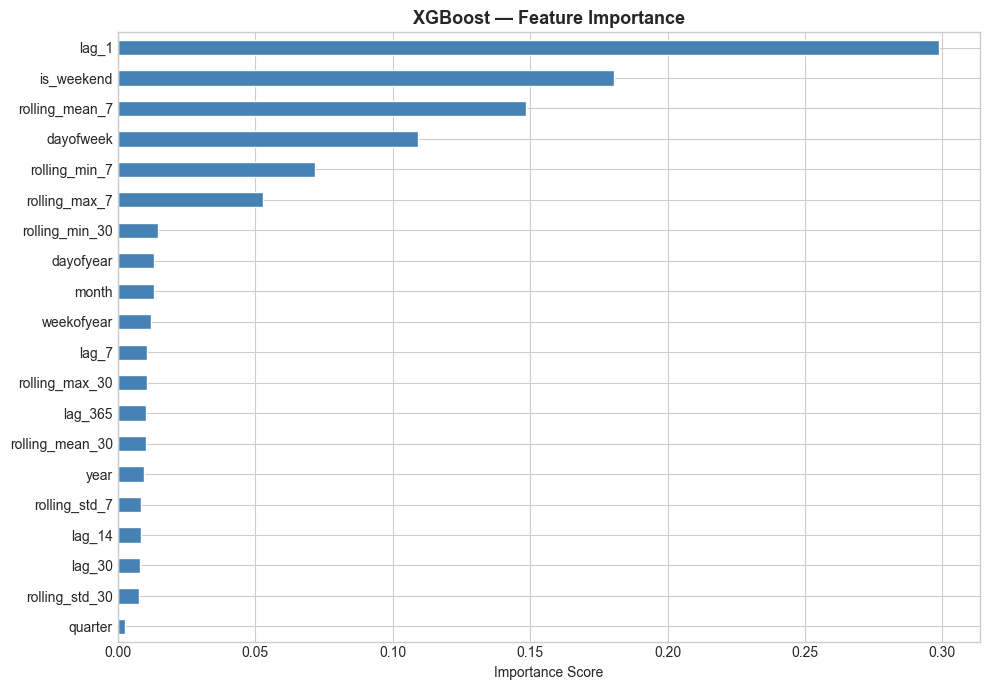

In [24]:
# Feature importance
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('XGBoost — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


📊 XGBoost Results:
  RMSE :     816.65 MW
  MAE  :     632.98 MW
  MAPE :       4.10 %


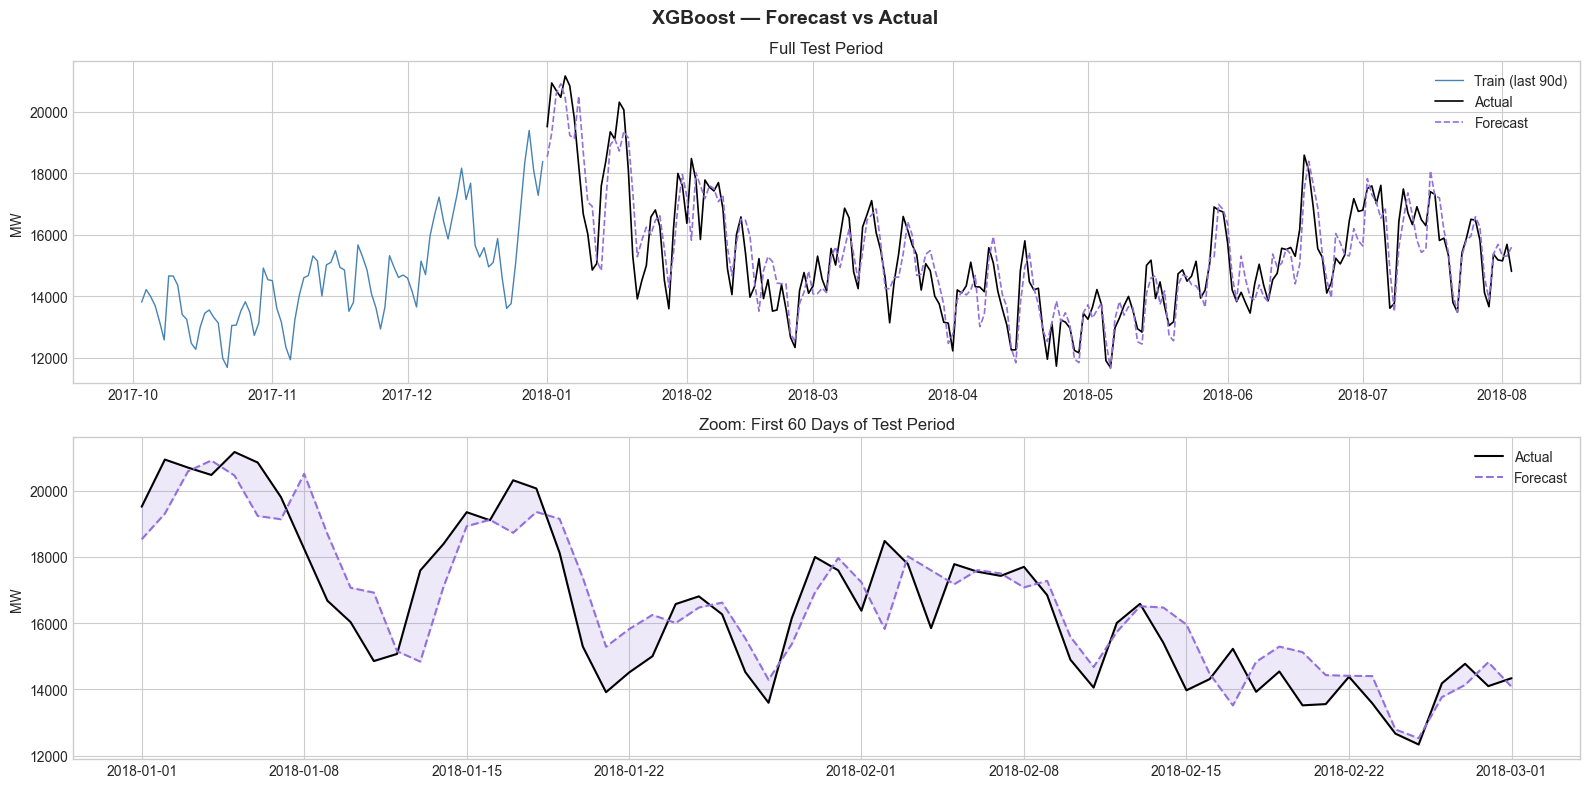

In [25]:
# Forecast
xgb_pred = xgb_model.predict(X_te)

# Evaluate  
xgb_metrics = evaluate_model(y_te.values, xgb_pred, 'XGBoost')
results.append(xgb_metrics)

# Align test index (may differ from original due to dropna)
test_xgb = y_te.copy()
plot_forecast(train, test_xgb, xgb_pred, 'XGBoost', color='mediumpurple')

---
## 10. 🏆 Model Comparison

In [26]:
results_df = pd.DataFrame(results).set_index('Model')

print('\n' + '='*55)
print('🏆 FINAL MODEL COMPARISON')
print('='*55)
print(results_df.round(2).to_string())
print('\n🥇 Best RMSE:', results_df['RMSE'].idxmin())
print('🥇 Best MAE :', results_df['MAE'].idxmin())
print('🥇 Best MAPE:', results_df['MAPE'].idxmin())


🏆 FINAL MODEL COMPARISON
            RMSE      MAE   MAPE
Model                           
SARIMAX  5212.72  4914.53  33.81
LSTM      788.04   618.69   4.03
XGBoost   816.65   632.98   4.10

🥇 Best RMSE: LSTM
🥇 Best MAE : LSTM
🥇 Best MAPE: LSTM


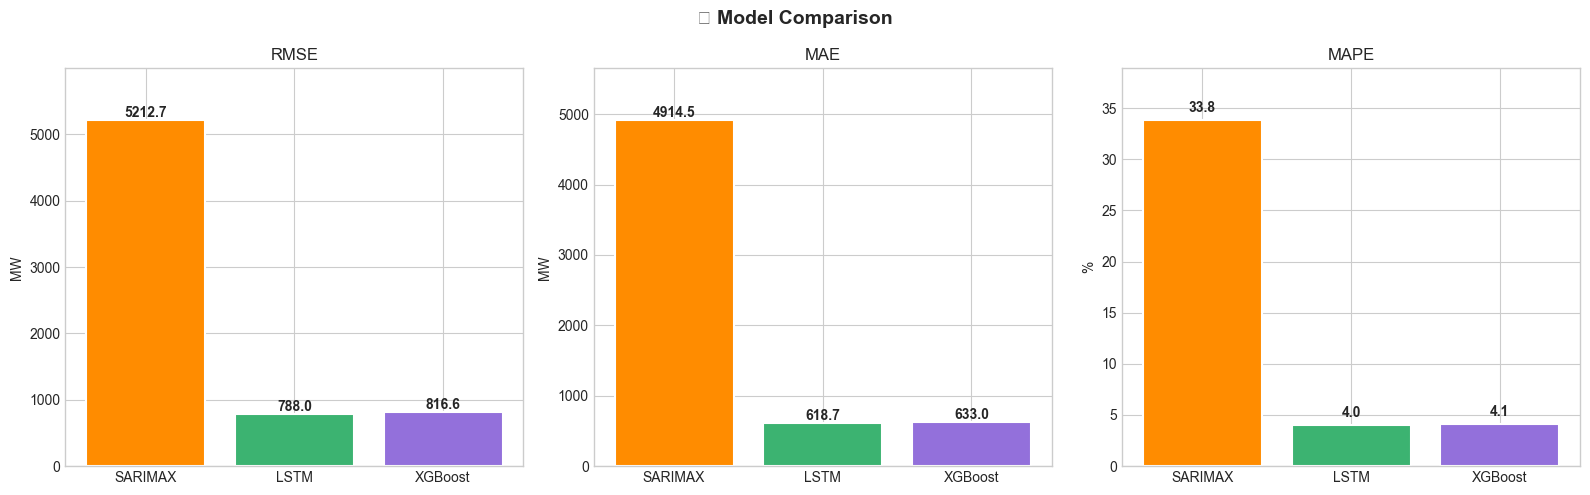

In [27]:
# Metrics bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('🏆 Model Comparison', fontsize=14, fontweight='bold')

colors = ['darkorange', 'mediumseagreen', 'mediumpurple']
metrics = ['RMSE', 'MAE', 'MAPE']
ylabels = ['MW', 'MW', '%']

for i, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    bars = axes[i].bar(results_df.index, results_df[metric], color=colors, edgecolor='white', linewidth=1.5)
    axes[i].set_title(metric)
    axes[i].set_ylabel(ylabel)
    # Annotate bars
    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    axes[i].set_ylim(0, results_df[metric].max() * 1.15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

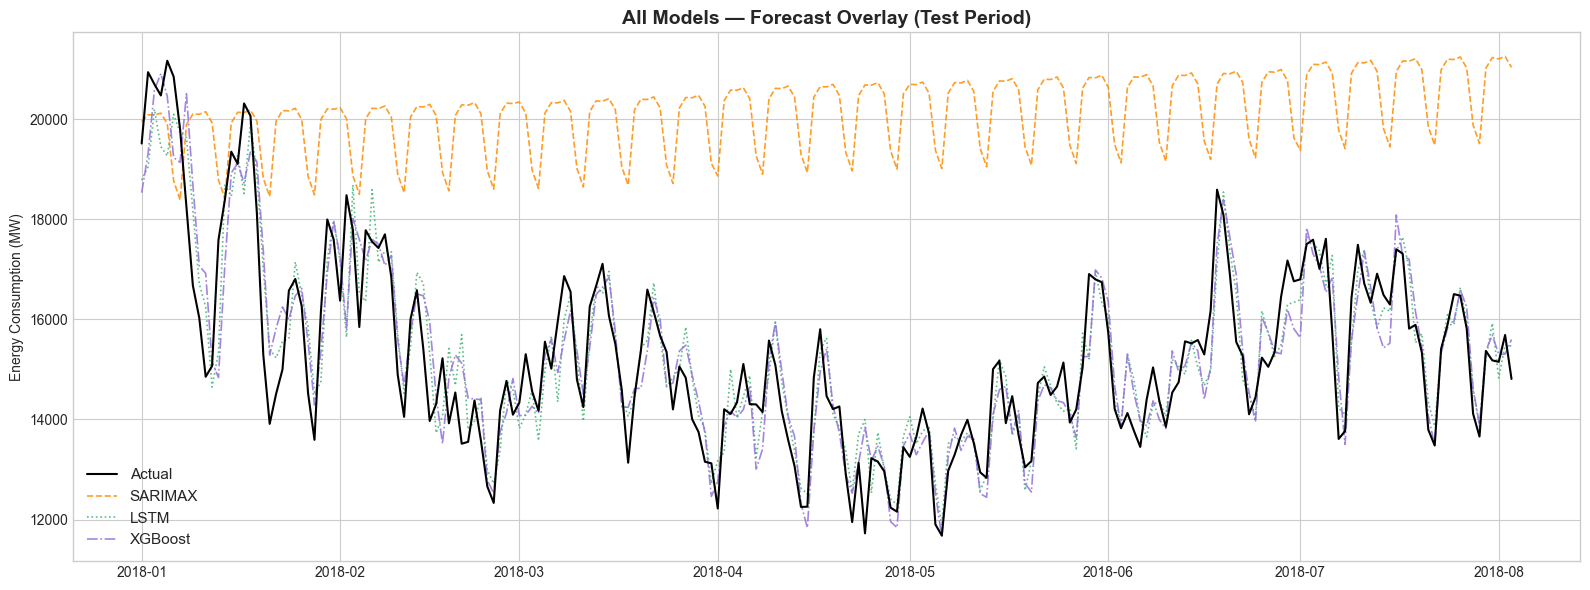

In [28]:
# Side-by-side forecast overlay
# Align all predictions to shared test index
shared_test_index = test.index[:len(xgb_pred)]   # use xgb index as reference

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(shared_test_index, test.loc[shared_test_index], label='Actual', 
        color='black', linewidth=1.5, zorder=5)
ax.plot(shared_test_index, sarimax_pred[:len(shared_test_index)], 
        label='SARIMAX',  color='darkorange',   linewidth=1.2, linestyle='--', alpha=0.85)
ax.plot(shared_test_index, lstm_pred[:len(shared_test_index)],    
        label='LSTM',     color='mediumseagreen', linewidth=1.2, linestyle=':',  alpha=0.85)
ax.plot(shared_test_index, xgb_pred[:len(shared_test_index)],    
        label='XGBoost',  color='mediumpurple',  linewidth=1.2, linestyle='-.', alpha=0.85)

ax.set_title('All Models — Forecast Overlay (Test Period)', fontsize=14, fontweight='bold')
ax.set_ylabel('Energy Consumption (MW)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('all_models_overlay.png', dpi=120, bbox_inches='tight')
plt.show()

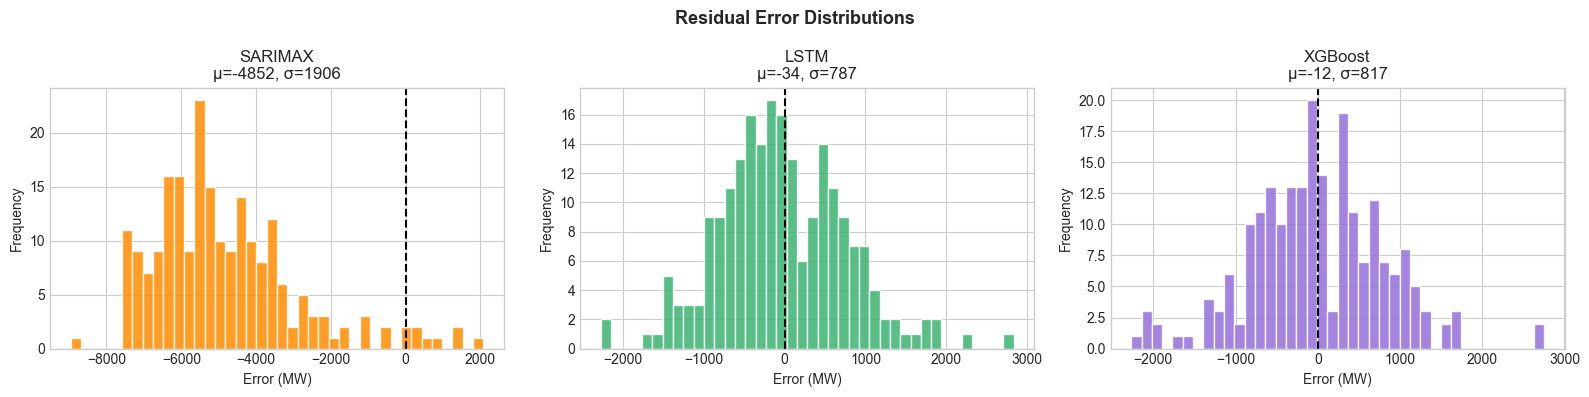

In [29]:
# Error distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Residual Error Distributions', fontsize=13, fontweight='bold')

n = min(len(sarimax_pred), len(lstm_pred), len(xgb_pred), len(test))
actual = test.values[:n]

errors = {
    'SARIMAX':  actual - sarimax_pred[:n],
    'LSTM':     actual - lstm_pred[:n],
    'XGBoost':  actual - xgb_pred[:n]
}

for ax, (name, err), color in zip(axes, errors.items(), colors):
    ax.hist(err, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_title(f'{name}\nμ={err.mean():.0f}, σ={err.std():.0f}')
    ax.set_xlabel('Error (MW)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('error_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 11. 📝 Conclusions & Model Summary


In [30]:
best_rmse = results_df['RMSE'].idxmin()
best_mape = results_df['MAPE'].idxmin()

print("""
╔══════════════════════════════════════════════════════════╗
║        PJM AEP FORECASTING — CONCLUSIONS                ║
╚══════════════════════════════════════════════════════════╝

📌 SARIMAX
   → Strengths : Interpretable, captures weekly seasonality,
                 uses exogenous features natively
   → Weaknesses: Assumes linearity, slow on large data,
                 limited to low-order complexity
   → Best for  : Baseline, reporting, regulated environments

📌 LSTM
   → Strengths : Captures long-range non-linear dependencies,
                 handles complex temporal patterns
   → Weaknesses: Needs more data/tuning, black-box,
                 slower training
   → Best for  : Multi-step ahead forecasting

📌 XGBoost
   → Strengths : Fast, feature-rich, handles non-linearity,
                 robust to outliers, interpretable with SHAP
   → Weaknesses: Needs careful lag engineering, not naturally
                 sequential
   → Best for  : Single-step ahead with rich feature sets
""")

print(results_df.round(2))
print(f'\n🏆 Best RMSE → {best_rmse}')
print(f'🏆 Best MAPE → {best_mape}')


╔══════════════════════════════════════════════════════════╗
║        PJM AEP FORECASTING — CONCLUSIONS                ║
╚══════════════════════════════════════════════════════════╝

📌 SARIMAX
   → Strengths : Interpretable, captures weekly seasonality,
                 uses exogenous features natively
   → Weaknesses: Assumes linearity, slow on large data,
                 limited to low-order complexity
   → Best for  : Baseline, reporting, regulated environments

📌 LSTM
   → Strengths : Captures long-range non-linear dependencies,
                 handles complex temporal patterns
   → Weaknesses: Needs more data/tuning, black-box,
                 slower training
   → Best for  : Multi-step ahead forecasting

📌 XGBoost
   → Strengths : Fast, feature-rich, handles non-linearity,
                 robust to outliers, interpretable with SHAP
   → Weaknesses: Needs careful lag engineering, not naturally
                 sequential
   → Best for  : Single-step ahead with rich feature se